In [13]:
import cv2
import numpy as np
image_path=r"/content/WhatsApp Image 2026-07-08 at 4.37.25 PM.jpeg"
image=cv2.imread(image_path)
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)


# 1- Sobel filter

array([[131, 115, 116, ..., 179,   0,   0],
       [113,  14,   9, ..., 120,   0,   0],
       [111,  19,  17, ..., 111,   0,   0],
       ...,
       [125, 110, 114, ..., 183,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
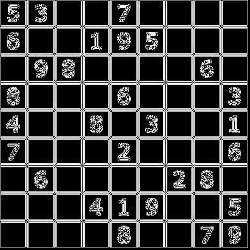

In [12]:
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
def sobel_filter(image):
    img_array = gray.astype(np.float64)
    height, width=img_array.shape
    sobel_x=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    sobel_y=np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
    output_arr=np.zeros((height,width))
    for i in range(height-2):
        for j in range(width-2):
            x=img_array[i:i+3,j:j+3]*sobel_x
            y=img_array[i:i+3,j:j+3]*sobel_y
            gx = np.sum(x)
            gy = np.sum(y)
            output_arr[i,j] = np.sqrt(gx**2 + gy**2)
    return output_arr.astype(np.uint8)
sobel_filter(image)

# 2-Gaussian filter

In [14]:
def apply_convolution(image, kernel, padding='same'):
    img_float = image.astype(np.float32)
    kernel_h, kernel_w = kernel.shape

    if padding == 'same':
        pad_h = kernel_h // 2
        pad_w = kernel_w // 2
        padded_img = np.pad(img_float, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    elif padding == 'valid':
        padded_img = img_float
    else:
        raise ValueError("padding must be 'same' or 'valid'")

    padded_h, padded_w = padded_img.shape
    output_h = padded_h - kernel_h + 1
    output_w = padded_w - kernel_w + 1

    output_image = np.zeros((output_h, output_w), dtype=np.float32)

    for i in range(output_h):
        for j in range(output_w):
            region = padded_img[i:i+kernel_h, j:j+kernel_w]
            output_image[i, j] = np.sum(region * kernel)

    return output_image

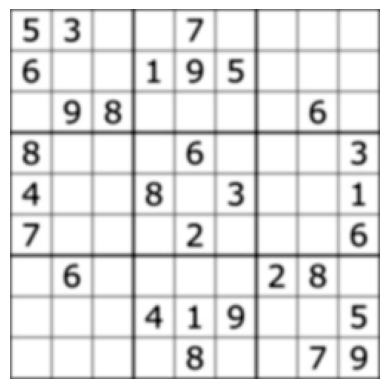

In [16]:
import matplotlib.pyplot as plt

def gaussian_kernel(size, sigma):
    kernel = np.zeros((size, size), dtype=np.float64)

    center = size // 2 #floor devision

    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center

            kernel[i, j] = np.exp(-(x*x + y*y)/(2*sigma*sigma))

    kernel /= np.sum(kernel)

    return kernel

def gaussian_blur(gray, kernel):
    k = kernel.shape[0]
    pad = k // 2

    padded = np.pad(gray, pad, mode='edge')

    output = np.zeros_like(gray)

    height, width = gray.shape

    for i in range(height):
        for j in range(width):

            region = padded[i:i+k, j:j+k]

            output[i, j] = np.sum(region * kernel)

    return output.astype(np.uint8)

kernel = gaussian_kernel(5, 1)

blurred = gaussian_blur(gray, kernel)

plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()